In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split

# Section 1 - Dataset Description and Experimental Design

In [ ]:
import numpy as np
import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)

## 1.1 Dataset Characteristics

In [7]:
#Loading in Dataset
df = pd.read_csv('../datasets/SMI_Train_4214293.csv')

In [12]:
# Display the shape of the dataset
df.shape

(8000, 171)

In [14]:
# Display a summary of the dataframe to verify column data types (ensuring sensors are float64) and check non-null counts.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Columns: 171 entries, class to Sensor_170
dtypes: int64(1), str(170)
memory usage: 10.4 MB


In [16]:
df.head()

,class,Sensor_001,Sensor_002,Sensor_003,Sensor_004,Sensor_005,Sensor_006,Sensor_007,Sensor_008,Sensor_009,...,Sensor_161,Sensor_162,Sensor_163,Sensor_164,Sensor_165,Sensor_166,Sensor_167,Sensor_168,Sensor_169,Sensor_170
0,neg,10,0,8,8,0,0,0,0,0,...,56,34,70,70,2,0,0,0,0,0
1,neg,1954,na,60,60,0,0,0,0,0,...,8628,4788,12536,63870,28,0,0,0,0,0
2,neg,29304,na,594,474,0,0,0,0,0,...,224856,101102,217024,253494,199228,117920,160068,10444,0,0
3,neg,33736,na,112,90,0,0,0,0,0,...,63708,39832,91816,183518,889270,174658,554,178,0,0
4,neg,24,na,62,42,0,0,0,0,0,...,344,46,8,0,0,0,0,0,0,0


In [ ]:
# Calculate and print the total number of observations in the dataset
total_obs = len(df)
print(f"Total observations: {total_obs}")

Total observations: 8000


In [18]:
# Calculate Class Imbalance
class_counts = df['class'].value_counts()
pos_count = class_counts.get('pos', 0)
neg_count = class_counts.get('neg', 0)
pos_pct = (pos_count / total_obs) * 100
neg_pct = (neg_count / total_obs) * 100

print(f"Positive class (pos): {pos_count} instances ({pos_pct:.2f}%)")
print(f"Negative class (neg): {neg_count} instances ({neg_pct:.2f}%)")

Positive class (pos): 133 instances (1.66%)
Negative class (neg): 7867 instances (98.34%)


C:\Users\yamee\AppData\Local\Temp\ipykernel_40932\4263011473.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='class', palette={'neg': 'blue', 'pos': 'red'})


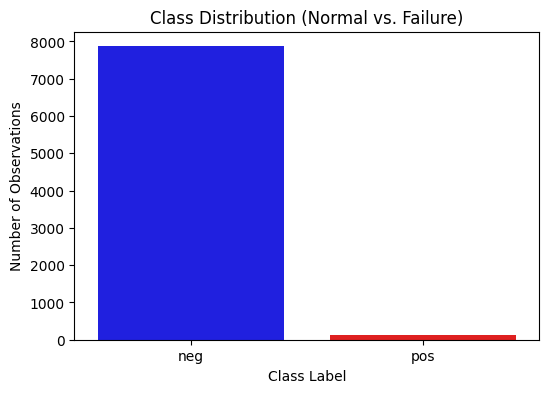

In [19]:
# Plot Class Imbalance (Save this plot for your report)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='class', palette={'neg': 'blue', 'pos': 'red'})
plt.title('Class Distribution (Normal vs. Failure)')
plt.ylabel('Number of Observations')
plt.xlabel('Class Label')
plt.show()

## 1.2 Data Quality and Missingness

In [20]:
# Replace 'na' strings with actual numpy NaN values
df.replace('na', np.nan, inplace=True)

,class,Sensor_001,Sensor_002,Sensor_003,Sensor_004,Sensor_005,Sensor_006,Sensor_007,Sensor_008,Sensor_009,...,Sensor_161,Sensor_162,Sensor_163,Sensor_164,Sensor_165,Sensor_166,Sensor_167,Sensor_168,Sensor_169,Sensor_170
0,neg,10,0,8,8,0,0,0,0,0,...,56,34,70,70,2,0,0,0,0,0
1,neg,1954,NaN,60,60,0,0,0,0,0,...,8628,4788,12536,63870,28,0,0,0,0,0
2,neg,29304,NaN,594,474,0,0,0,0,0,...,224856,101102,217024,253494,199228,117920,160068,10444,0,0
3,neg,33736,NaN,112,90,0,0,0,0,0,...,63708,39832,91816,183518,889270,174658,554,178,0,0
4,neg,24,NaN,62,42,0,0,0,0,0,...,344,46,8,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,neg,1730,NaN,2130706432,20,0,0,0,0,0,...,6704,4706,30222,39864,140,0,0,0,0,0
7996,neg,28,NaN,42,36,0,0,0,0,0,...,594,98,28,0,0,0,0,0,0,0
7997,neg,58206,NaN,2130706432,218,0,0,0,0,0,...,311024,147776,305886,242466,234308,231342,942242,660,0,0
7998,neg,14,NaN,30,NaN,0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


In [21]:
# Convert all sensor columns from object to numeric (float)
sensor_cols = [col for col in df.columns if 'Sensor' in col]
df[sensor_cols] = df[sensor_cols].apply(pd.to_numeric)

In [22]:
# Calculate overall missingness
total_cells = df[sensor_cols].size
missing_cells = df[sensor_cols].isna().sum().sum()
overall_missing_pct = (missing_cells / total_cells) * 100
print(f"Overall dataset missingness: {overall_missing_pct:.2f}%")

Overall dataset missingness: 8.29%


In [23]:
# Calculate missingness per feature
missing_per_feature = df[sensor_cols].isna().sum()
features_with_missing = (missing_per_feature > 0).sum()
print(f"Number of features with missing values: {features_with_missing}")

Number of features with missing values: 169


In [24]:
# Find the feature with the highest missingness
highest_missing_col = missing_per_feature.idxmax()
highest_missing_count = missing_per_feature.max()
highest_missing_pct = (highest_missing_count / total_obs) * 100
print(f"Feature with the highest missingness: {highest_missing_col} ({highest_missing_pct:.2f}%)")

Feature with the highest missingness: Sensor_079 (82.11%)


In [ ]:
# Per-feature missing rate (%) — used for colour-coded bar chart below
miss_pct = (missing_per_feature / total_obs * 100).round(2)

# Class masks for conditional analysis
pos_mask = df['class'] == 'pos'
neg_mask = df['class'] == 'neg'

In [ ]:
# Per-feature missing rate split by class
miss_pos = df[sensor_cols][pos_mask].isnull().mean() * 100
miss_neg = df[sensor_cols][neg_mask].isnull().mean() * 100

# Rank features by size of the pos-neg missingness gap
miss_diff = (miss_pos - miss_neg).sort_values(ascending=False)

print(f'Missing rate — Pos: {miss_pos.mean():.2f}%  |  Neg: {miss_neg.mean():.2f}%')
print(f'→ Failures have {miss_pos.mean()/miss_neg.mean():.1f}× more missing values (informative missingness)')

In [ ]:
# Colour-code bars by missingness severity: red >30%, orange 10-30%, yellow <10%
feat_miss = miss_pct[miss_pct > 0].sort_values(ascending=False)
colors = ['#F44336' if v > 30 else '#FF9800' if v > 10 else '#FFC107' for v in feat_miss.values]

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(len(feat_miss)), feat_miss.values, color=colors, width=1.0)
ax.axhline(10, color='#FF9800', linestyle='--', linewidth=1.2)
ax.axhline(30, color='#F44336', linestyle='--', linewidth=1.2)
ax.legend(handles=[
    mpatches.Patch(color='#F44336', label=f">30% missing  ({(miss_pct > 30).sum()} features)"),
    mpatches.Patch(color='#FF9800', label=f"10–30% missing ({((miss_pct > 10) & (miss_pct <= 30)).sum()} features)"),
    mpatches.Patch(color='#FFC107', label=f"<10% missing  ({((miss_pct > 0) & (miss_pct <= 10)).sum()} features)"),
], fontsize=9)
ax.set_title('Missing Value Rate per Feature (sorted descending)')
ax.set_xlabel('Features (sorted by missing rate)')
ax.set_ylabel('Missing Rate (%)')
plt.tight_layout()
plt.show()

In [ ]:
# Select the 12 features where the pos-neg missingness gap is largest
top_diff_feats = miss_diff.nlargest(12).index
x, w = np.arange(len(top_diff_feats)), 0.35

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(x - w/2, miss_pos[top_diff_feats].values, w, label='Positive (Failure)', color='#F44336', alpha=0.85)
ax.bar(x + w/2, miss_neg[top_diff_feats].values, w, label='Negative (Normal)',  color='#2196F3', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top_diff_feats, rotation=40, ha='right', fontsize=9)
ax.set_title('Missing Rate by Class — Top 12 Features with Largest Discrepancy')
ax.set_ylabel('Missing Rate (%)')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 1.3 Feature Relevance & Correlation

In [ ]:
# Class-conditional mean difference — ranks features by discriminative power
mean_diff = (df[sensor_cols][pos_mask].mean() - df[sensor_cols][neg_mask].mean()).abs()

# Spearman correlation — robust to the extreme skew present in sensor data
print('Computing Spearman correlation matrix...')
corr_matrix = df[sensor_cols].corr(method='spearman')

# Upper triangle only — avoids double-counting pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
print(f'Feature pairs |corr| > 0.95 : {(upper.abs() > 0.95).sum().sum()}')
print(f'Feature pairs |corr| > 0.80 : {(upper.abs() > 0.80).sum().sum()}')

In [ ]:
# Restrict heatmap to the 20 most discriminating features to keep it readable
top20_feats = mean_diff.nlargest(20).index.tolist()
corr_sub    = corr_matrix.loc[top20_feats, top20_feats]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_sub, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.7})
ax.tick_params(labelsize=8)
ax.set_title('Spearman Correlation — Top 20 Discriminating Features', pad=12)
plt.tight_layout()
plt.show()

## 1.4 Experimental Design

In [25]:
# Separate features (X) and target (y)
X = df.drop('class', axis=1)
y = df['class']

# Perform a stratified 80/20 train-test split to prevent leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print("\n--- Experimental Split ---")
print(f"Training set size: {len(X_train)} observations")
print(f"Test set size: {len(X_test)} observations (Held out for final benchmarking)")


--- Experimental Split ---
Training set size: 6400 observations
Test set size: 1600 observations (Held out for final benchmarking)
